In [18]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import cKDTree
from tqdm import tqdm
from numba import jit

### Inputs

In [19]:
#Inputs
ticker = '^GSPC'

# Fetch data
df = yf.download(tickers = ticker, start='2000-01-01', interval="1d")
df['returns'] = np.log(df['Close']) - np.log(df['Close']).shift(1)
df.dropna(inplace = True)
df = df[['Close', 'returns']]

[*********************100%***********************]  1 of 1 completed


### Functions (Entropy, MI, Hurst)

In [20]:
# Entropy

def shannon_entropy(x, bins: int = 30, normalize: bool = True) -> float:
    x = np.asarray(x, dtype = float)
    if np.allclose(np.std(x), 0):
        x = x + 1e-12 * np.random.randn(*x.shape)
    counts, _ = np.histogram(x, bins = bins)
    p = counts / counts.sum()
    p = p[p > 0]
    H = - np.sum(p * np.log2(p))
    if not normalize:
        return float(H)
    Hmax = np.log2(len(counts))
    return float(H / Hmax) if Hmax > 0 else np.nan

entropy_val = shannon_entropy(df['returns'], bins = 30, normalize = True)

# Mutual Information

def _mutual_information_norm(x: np.ndarray, y: np.ndarray, bins: int = 30) -> float:

    counts_x, _ = np.histogram(x, bins=bins)
    counts_y, _ = np.histogram(y, bins=bins)
    counts_xy, _, _ = np.histogram2d(x, y, bins=(bins, bins))

 
    def H(counts):
        p = counts / counts.sum()
        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    Hx = H(counts_x)
    Hy = H(counts_y)
    Hxy = H(counts_xy.ravel())

    MI = Hx + Hy - Hxy
    return float(MI / Hx) if Hx > 0 else np.nan

t=1

mi_norm = _mutual_information_norm(df['returns'][t:], df['returns'][:-1], bins = 30)

# Hurst Exponent

@jit(nopython=True)
def get_rs_vals(x, sizes):
    
    N = len(x)
    RS_pairs = []
    
    for w in sizes:
        if w < 2:
            continue
        n_seg = N // w
        rs_vals_w = []
        for i in range(n_seg):
            seg = x[i*w:(i+1)*w]
            mean_seg = np.sum(seg) / w
            
            Y = np.cumsum(seg - mean_seg)
            R = np.max(Y) - np.min(Y)
            S = np.std(seg)
            
            if S > 0:
                rs_vals_w.append(R / S)
                
        if len(rs_vals_w) > 0:
            mean_rs = np.sum(np.array(rs_vals_w)) / len(rs_vals_w)
            RS_pairs.append((w, mean_rs))
            
    return RS_pairs

def _hurst_exponent_rs(x: np.ndarray, min_window: int = 16) -> float:
    x = np.asarray(x, dtype=float)
    N = len(x)
    max_window = N // 2
    
    sizes = np.unique(np.geomspace(min_window, max_window, num=20).astype(int))

    RS = get_rs_vals(x, sizes)

    if not RS:
        return np.nan
    
    w_arr = np.array([item[0] for item in RS])
    rs_arr = np.array([item[1] for item in RS])

    H, _ = np.polyfit(np.log(w_arr), np.log(rs_arr), 1)
    
    return float(H)

hurst_exp = _hurst_exponent_rs(df['returns'].values, min_window = 16)

### Output

In [21]:
def generate_daily_physics(df, window=252):
    returns_array = df['returns'].values
    n_days = len(returns_array)
    
    daily_hurst = np.full(n_days, np.nan)
    daily_entropy = np.full(n_days, np.nan)
    daily_mi = np.full(n_days, np.nan)
    
    print(f"Calcul des indicateurs sur {n_days - window} jours...")
    
    for i in tqdm(range(window, n_days)):
        window_returns = returns_array[i - window : i]
        
        daily_entropy[i] = shannon_entropy(window_returns, bins=30, normalize=True)
        daily_hurst[i] = _hurst_exponent_rs(window_returns, min_window=16)
        
        x_mi = window_returns[1:]
        y_mi = window_returns[:-1]
        daily_mi[i] = _mutual_information_norm(x_mi, y_mi, bins=30)
        
    result_df = df.copy()
    result_df['Hurst'] = daily_hurst
    result_df['Entropy'] = daily_entropy
    result_df['MI_Norm'] = daily_mi
    
    return result_df


def calculate_dynamic_thresholds(df, window=252):
    df_calc = df.copy()
    
    df_calc['Hurst_Upper'] = df_calc['Hurst'].rolling(window=window).quantile(0.70)
    df_calc['Hurst_Lower'] = df_calc['Hurst'].rolling(window=window).quantile(0.30)
    
    ent_mean = df_calc['Entropy'].rolling(window=window).mean()
    ent_std = df_calc['Entropy'].rolling(window=window).std()
    df_calc['Entropy_Thresh'] = ent_mean + (1.0 * ent_std) 
    
    df_calc['MI_Thresh'] = df_calc['MI_Norm'].rolling(window=window).median()
    
    return df_calc.dropna()


def interpret_market_physics_dynamic(hurst, entropy, mi_norm, thresholds):
    # 1 : Define physical states
    if hurst > thresholds['Hurst_Upper']:
        mem_state = "PERSISTENT"
    elif hurst < thresholds['Hurst_Lower']:
        mem_state = "MEAN_REVERTING"
    else:
        mem_state = "RANDOM_WALK"

    struct_state = "ORDERED" if entropy < thresholds['Entropy_Thresh'] else "DISORDERED"
    info_state = "CONNECTED" if mi_norm > thresholds['MI_Thresh'] else "DISCONNECTED"

    # 2 : Decision matrix
    regime = "UNDEFINED"
    action = "WAIT"
    risk_level = 0.5 

    if mem_state == "PERSISTENT" and struct_state == "ORDERED":
        regime = "LAMINAR TREND"
        action = "AGGRESSIVE LONG"
        risk_level = 0.2 
        description = "Clean trending flow. Low resistance."

    elif mem_state == "PERSISTENT" and struct_state == "DISORDERED" and info_state == "DISCONNECTED":
        regime = "STRUCTURAL TIME BOMB"
        action = "HEDGE / REDUCE"
        risk_level = 0.9 
        description = "Forced rise in disorder. Risk of violent rupture."

    elif struct_state == "DISORDERED" and mem_state != "PERSISTENT":
        regime = "NOISE / CHOP"
        action = "CASH IS KING"
        risk_level = 0.8
        description = "Pure noise. No exploitable structure."

    elif mem_state == "PERSISTENT" and struct_state == "ORDERED" and info_state == "DISCONNECTED":
        regime = "COMPRESSION"
        action = "WAIT FOR BREAKOUT"
        risk_level = 0.4
        description = "'Smooth' move but disconnected info. Calm before the storm?"

    elif mem_state == "MEAN_REVERTING" and struct_state == "ORDERED":
        regime = "OSCILLATOR"
        action = "FADE EXTREMES"
        risk_level = 0.3
        description = "Clean range. Buy low, sell high."

    else:
        regime = "TRANSITION"
        description = "Hybrid or unstable state."

    return {
        "Regime": regime,
        "Action": action,
        "Risk_Score": risk_level,
        "Description": description,
        "Details": f"{mem_state} | {struct_state} | {info_state}"
    }


df_with_physics = generate_daily_physics(df, window=252)
df_final = calculate_dynamic_thresholds(df_with_physics, window=252)

# Print
hurst_val = float(df_final['Hurst'].iloc[-1])
entropy_val = float(df_final['Entropy'].iloc[-1])
mi_val = float(df_final['MI_Norm'].iloc[-1])

print("="*45)
print("   ÉTAT PHYSIQUE DU MARCHÉ (Dernière clôture)   ")
print("="*45)
print(f"Exposant de Hurst      : {hurst_val:.4f}")
print(f"Entropie de Shannon    : {entropy_val:.4f}")
print(f"Information Mutuelle   : {mi_val:.4f}")
print("-" * 45)

current_thresholds = {
    'Hurst_Upper': float(df_final['Hurst_Upper'].iloc[-1]),
    'Hurst_Lower': float(df_final['Hurst_Lower'].iloc[-1]),
    'Entropy_Thresh': float(df_final['Entropy_Thresh'].iloc[-1]),
    'MI_Thresh': float(df_final['MI_Thresh'].iloc[-1])
}

decision = interpret_market_physics_dynamic(
    hurst=hurst_val, 
    entropy=entropy_val, 
    mi_norm=mi_val, 
    thresholds=current_thresholds
)

print("\n>>> DÉCISION DE L'ALGORITHME <<<")
print(f"Régime Détecté : {decision['Regime']}")
print(f"Action Requise : {decision['Action']}")
print(f"Niveau Risque  : {decision['Risk_Score']}")
print(f"Description    : {decision['Description']}")
print(f"Détails Bruts  : {decision['Details']}\n")

Calcul des indicateurs sur 6403 jours...


100%|██████████| 6403/6403 [00:02<00:00, 2327.65it/s]

   ÉTAT PHYSIQUE DU MARCHÉ (Dernière clôture)   
Exposant de Hurst      : 0.5404
Entropie de Shannon    : 0.8053
Information Mutuelle   : 0.2394
---------------------------------------------

>>> DÉCISION DE L'ALGORITHME <<<
Régime Détecté : TRANSITION
Action Requise : WAIT
Niveau Risque  : 0.5
Description    : Hybrid or unstable state.
Détails Bruts  : PERSISTENT | DISORDERED | CONNECTED



### Backtest

Lancement du Backtest
     RÉSULTATS DU BACKTEST NET DE FRAIS (Depuis l'an 2000)     
Buy & Hold (Passif)       | Perf:  313.30% | Max Drawdown:  -61.03%
Stratégie Physique (Brute)| Perf:  153.31% | Max Drawdown:  -35.38%
Stratégie Physique (Nette)| Perf:   37.72% | Max Drawdown:  -37.37%


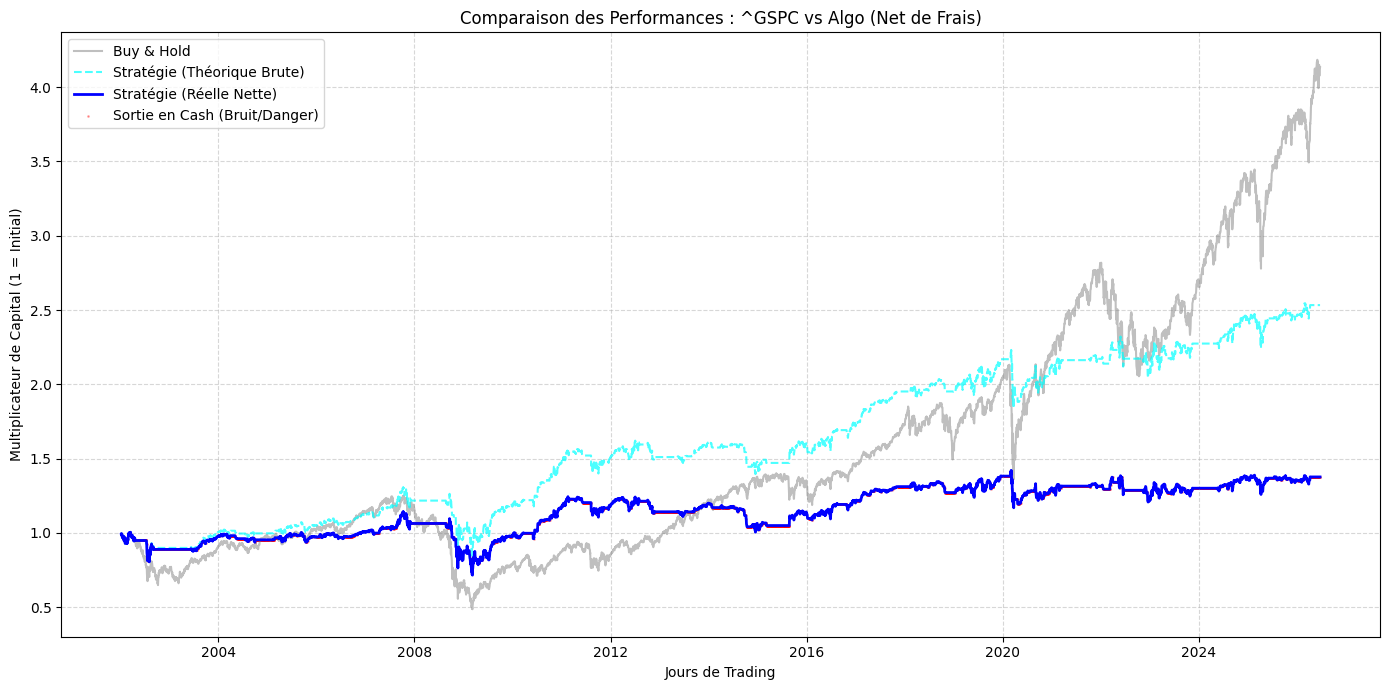

In [22]:
print("Lancement du Backtest")

def get_daily_position(row):
    def safe_val(col_name):
        val = row[col_name]
        if isinstance(val, pd.Series):
            return float(val.iloc[0])
        return float(val)

    thresholds = {
        'Hurst_Upper': safe_val('Hurst_Upper'),
        'Hurst_Lower': safe_val('Hurst_Lower'),
        'Entropy_Thresh': safe_val('Entropy_Thresh'),
        'MI_Thresh': safe_val('MI_Thresh')
    }
    
    decision = interpret_market_physics_dynamic(
        hurst=safe_val('Hurst'), 
        entropy=safe_val('Entropy'), 
        mi_norm=safe_val('MI_Norm'), 
        thresholds=thresholds
    )
    
    action = decision['Action']
    
    if action == "AGGRESSIVE LONG":
        return 1.0   
    elif action == "FADE EXTREMES":
        return 0.5   
    elif action == "HEDGE / REDUCE":
        return -0.5  
    else:
        return 0.0   

# Calc
df_final['Target_Position'] = df_final.apply(get_daily_position, axis=1)
df_final['Actual_Position'] = df_final['Target_Position'].shift(1)


df_final['Strat_Returns'] = df_final['Actual_Position'] * df_final['returns']

transaction_cost = 0.001  
df_final['Position_Change'] = df_final['Actual_Position'].diff().abs().fillna(0)
df_final['Strat_Returns_Net'] = df_final['Strat_Returns'] - (df_final['Position_Change'] * transaction_cost)

df_final['B&H_Equity'] = (1 + df_final['returns']).cumprod()
df_final['Strat_Equity'] = (1 + df_final['Strat_Returns']).cumprod()
df_final['Strat_Equity_Net'] = (1 + df_final['Strat_Returns_Net']).cumprod()

total_return_bh = (df_final['B&H_Equity'].iloc[-1] - 1) * 100
total_return_strat = (df_final['Strat_Equity'].iloc[-1] - 1) * 100
total_return_strat_net = (df_final['Strat_Equity_Net'].iloc[-1] - 1) * 100

def get_max_drawdown(equity_curve):
    rolling_max = equity_curve.cummax()
    drawdown = equity_curve / rolling_max - 1.0
    return drawdown.min() * 100

dd_bh = get_max_drawdown(df_final['B&H_Equity'])
dd_strat = get_max_drawdown(df_final['Strat_Equity'])
dd_strat_net = get_max_drawdown(df_final['Strat_Equity_Net'])

# Print

print("="*65)
print("     RÉSULTATS DU BACKTEST NET DE FRAIS (Depuis l'an 2000)     ")
print("="*65)
print(f"Buy & Hold (Passif)       | Perf: {total_return_bh:>7.2f}% | Max Drawdown: {dd_bh:>7.2f}%")
print(f"Stratégie Physique (Brute)| Perf: {total_return_strat:>7.2f}% | Max Drawdown: {dd_strat:>7.2f}%")
print(f"Stratégie Physique (Nette)| Perf: {total_return_strat_net:>7.2f}% | Max Drawdown: {dd_strat_net:>7.2f}%")
print("="*65)

# Plot

plt.figure(figsize=(14, 7))
plt.plot(df_final.index, df_final['B&H_Equity'], label='Buy & Hold', color='gray', alpha=0.5)
plt.plot(df_final.index, df_final['Strat_Equity'], label='Stratégie (Théorique Brute)', color='cyan', linestyle='--', alpha=0.7)
plt.plot(df_final.index, df_final['Strat_Equity_Net'], label='Stratégie (Réelle Nette)', color='blue', linewidth=2)


cash_periods = df_final[df_final['Actual_Position'] == 0.0].index
plt.scatter(cash_periods, df_final.loc[cash_periods, 'Strat_Equity_Net'], color='red', s=1, alpha=0.3, label='Sortie en Cash (Bruit/Danger)')

plt.title(rf'Comparaison des Performances : {ticker} vs Algo (Net de Frais)')
plt.ylabel('Multiplicateur de Capital (1 = Initial)')
plt.xlabel('Jours de Trading')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()